## Why Model Stability Matters

- Models assume that the data distribution during training is similar to the data distribution during deployment.

- If the real-world data distribution changes, the patterns learned during training may no longer hold, which can lead to degraded model performance.

### Why might model performance degrade after deployment?
- Model performance degrades after deployment primarily due to changes in real-world data and environments that were not present during training. This degradation is not a flaw in the model itself but a natural consequence of its interaction with evolving data.

### What types of data changes can cause this?
- This are some common type of data changes that degrades performance :-
    - covariate shift, where feature distributions change
    - concept drift, where the relationship between features and the target changes
    - target distribution shifts where the class balance changes. 
    - Data quality issues and feedback loops can also introduce differences between training and production data, causing the model's predictions to become less accurate.

### Why does classical validation not detect this problem?
- Because all evaluation data comes from that same historical dataset used during training.

### Can a model still produce confident predictions while being wrong?
- Even when these relationships change, the model continues making predictions with high confidence because it has no awareness that the underlying patterns have shifted.

## Training Distribution vs Real-World Distribution

### What is Training distribution?
- Training distribution represents the statistical properties of the dataset used to train the model.

- This includes:
    - distribution of feature values
    - frequency of each class
    - relationships between features and the target
    - correlations between variables

- In other words, it describes how the data used during training is generated.

### What is Real-World distribution?
- Real-world distribution represents the statistical properties of the data the model receives after deployment.

- This includes:
    - feature distributions of new incoming data
    - frequency of classes in real usage
    - relationships between features and the target in the current environment

### What happens if the real-world data distribution shifts?
- The real-world distribution may differ from the training distribution because real systems evolve over time and when this shift happens models performance degrades. 

### Why is this dangerous for supervised models?
- Supervised models assume that the statistical properties of the training data remain similar after deployment. If the real-world data distribution shifts, the learned relationships may no longer be valid, leading to degraded model performance.

## Types of Dataset Shift

### What is covariate shift?
- Covariate shift occurs when the distribution of features changes, but the relationship between features and target remains the same.

- Example :- 
    - Training Data : Most Frequent users : age 25-40
    - Real-World Data : Most Frequent users : age 18-25

- The model still understands how age relates to frequency of user, but it is now seeing feature regions that were less common during training.

- Risk: The model may perform poorly because it was not exposed to these regions often.

### What is label shift?
- Label shift occurs when the distribution of the target variable changes (How many times class appears in dataset changes), while the feature distribution conditional on the label remains the same (What conditions leads to prediction of this class remains same).

- Example :-
    - Training data : Default rate = 20%
    - Real-World data : Default rate = 35%

- Risk: The model may underestimate default probability because it was trained under a different class balance.

### What is concept drift?
- Concept drift occurs when the relationship between features and the target changes.

- Example :-
    - Training Patter : High credit utilization → high default risk
    - Real-World situation: Even moderate utilization now leads to default due to economic changes

- Risk: The model’s learned rules are no longer valid.

- Concept drift is the most dangerous type of shift because the model’s decision boundaries become fundamentally incorrect.

## Requirements

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("cleaned_data.csv")

x = df.drop("default_payment_next_month", axis=1)
y = df["default_payment_next_month"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

## Detecting Feature Drift

- As model is not currently in deployment we do not have new data so lets use test data as new data for the time being.

In [3]:
x_test

,id,limit_bal,sex,education,marriage,age,pay_1,pay_2,pay_3,pay_4,...,bill_amt3,bill_amt4,bill_amt5,bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6
8681,8688,50000,2,3,1,43,0,0,0,0,...,17070,13038,8904,4740,2000,1500,3500,600,500,4000
24179,24202,240000,1,2,1,31,0,0,0,0,...,176012,179175,180809,184383,7648,7900,8000,6500,6900,7000
27755,27783,90000,2,1,2,25,0,0,0,0,...,8848,10135,11731,8138,1500,1500,1500,2000,1500,1000
14938,14948,50000,2,2,2,22,0,0,2,0,...,28301,26829,27173,26424,4809,0,1200,1500,943,1142
1486,1487,230000,1,1,2,32,0,0,0,0,...,29582,38426,42500,43531,10120,20000,10000,5000,5000,5000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9140,9147,70000,2,3,1,35,3,2,2,2,...,28650,27590,27850,28085,0,2708,0,1010,1013,2000
20329,20347,60000,2,3,1,66,0,0,2,2,...,54784,58232,61670,65120,5000,5000,5000,5000,5000,1000
20048,20066,30000,2,1,2,43,0,0,0,0,...,29417,30379,30452,0,1659,1589,1551,1124,0,0
154,155,30000,2,3,2,26,0,0,0,0,...,11427,11935,13084,14206,1700,1500,1000,1500,1500,1500


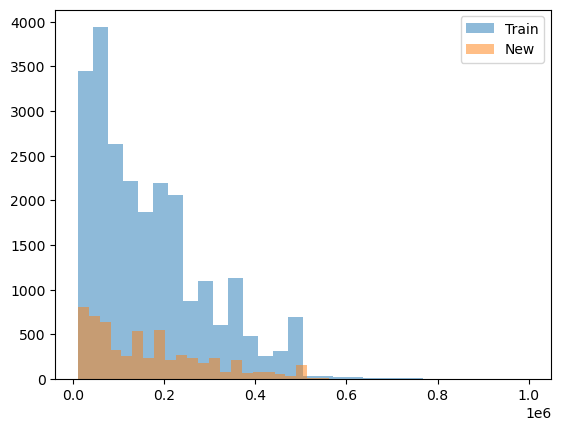

In [6]:
import matplotlib.pyplot as plt

new_data = x_test

plt.hist(x=x_train['limit_bal'], bins=30, alpha=0.5)
plt.hist(x=new_data['limit_bal'], bins=30, alpha=0.5)

plt.legend(["Train", "New"])
plt.show()

### What patterns would indicate drift?
- If both pattern are not similar to each other then this indicates drift. It says that model has not seen distribution like new data in its training phase.

### How could drift affect predictions?
- Drift causes the input data to move away from the distribution the model was trained on. 
Since the model’s learned patterns depend on the training distribution, predictions can become less accurate, biased, or poorly calibrated when drift occurs.

## Population Stability Index

- Population Stability Index is a metric used to measure how much the distribution of a feature changes between two datasets (training and new production)
- It is calculated by :

    $$PSI = \sum^{B}_{i=1} (Actual_i - Expected_i)\ * \ \ln(\frac{Actual_i}{Expected_i}) $$

    Where:

    - $ \text{Actual}_i $ is the percentage of observations in bin $ i $ of the target or current dataset,
    - $ B $ is the total number of bins,
    - $ \text{Expected}_i $ is the percentage of observations in bin $ i $ of the reference or baseline dataset,
    - $ \ln $ is the natural logarithm. 

### Why is PSI useful for monitoring?
- Because it quantifies change in distribution between training and new production dataset.

### What PSI ranges typically indicate concern?
- PSI < 0.1   → No significant drift
- 0.1–0.25    → Moderate shift
- PSI > 0.25  → Major distribution change

- If PSI is large, the model may require:
    - monitoring
    - investigation
    - retraining

## Prediction Drift

- Prediction Drift measures change in the distribution of the **model's prediction** output over time.

### What happens if the average predicted probability changes significantly?
- If average prediction probability changes significantly it indicates drift has occurred which may be due to many reasons like change in relationship between target and feature and as all the drifts are mentioned in types of drifts section.

### Could prediction drift appear even if features remain stable?
- Even if the feature remains stable relationship between feature and target can still change which can cause conceptual drift and class frequency can still change which could result in prediction drift.

## Data Quality Drift

- Data quality drift occurs when instead of change in it's statistical distribution data being fed to the model is incomplete, inconsistent or incorrectly formatted.

### What happens if missing values increase?
- If missing values increases model has to heavily rely on imputation or default values instead of actual values which may degrade performance of model.

### What if feature encoding changes?
- If encoding changes then model will interpret it incorrectly and which intern decreases performance by making incorrect predictions.

## Monitoring Strategy

- Feature Distribution Monitoring
    - Track whether the distribution of input features changes compared to training data by tracking :
        - histogram comparison
        - PSI (Population Stability Index)
        - statistical tests for distribution shift

- Prediction Distribution Monitoring
    - Monitor how model's outputs change overtime by tracing :
        - Average predicted probability
        - Distribution of prediction scores
        - Proportion of positive predictions

- Model Performance Monitoring
    - When true labels become available, monitor actual performance metrics by calculating :
        - Accuracy
        - Precision
        - Recall
        - F1 score
        - ROC-AUC

- Data Quality Monitoring
    - Monitor integrity of incoming data by checking for :
        - Accuracy
        - Precision
        - Recall
        - F1 score
        - ROC-AUC

